# Data Preprocessing

In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load dataset
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\block_code\dataset\synthetic_upi_transactions.csv")
# Display basic info  
print(df.info())  
print(df.head())

# Convert timestamp to datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract time-based features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Encode categorical features
label_encoders = {}
categorical_cols = ['location', 'transaction_type', 'device_id']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save for later use (e.g., API input processing)

# Drop unused columns
df = df.drop(columns=['transaction_id', 'user_id', 'timestamp'])

# Separate features and target
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Normalize numerical features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Preprocessing complete. Feature matrix shape:", X_scaled.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    10000 non-null  object 
 1   user_id           10000 non-null  object 
 2   amount            10000 non-null  float64
 3   timestamp         10000 non-null  object 
 4   location          10000 non-null  object 
 5   transaction_type  10000 non-null  object 
 6   device_id         10000 non-null  object 
 7   is_fraud          10000 non-null  int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 625.1+ KB
None
  transaction_id   user_id     amount            timestamp   location  \
0      TXN100000  USER3955    8274.89  2025-02-07 10:26:29      Delhi   
1      TXN100001  USER6116   24531.55  2025-01-20 07:07:29       Pune   
2      TXN100002  USER6506   30264.13  2025-03-23 04:16:29    Chennai   
3      TXN100003  USER4386     762.08  2025-03-31 21:30:29    

# SMOTE + SelectKBest

1 features - F1 Score: 0.3603
2 features - F1 Score: 0.4105
3 features - F1 Score: 0.4125
4 features - F1 Score: 0.4132
5 features - F1 Score: 0.4139
6 features - F1 Score: 0.4139
7 features - F1 Score: 0.4125


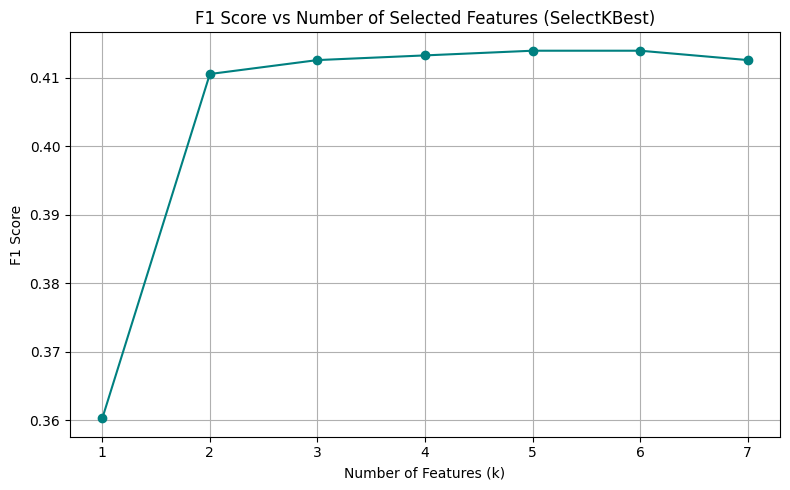


Optimal number of features: 5, Best F1 Score: 0.4139


In [23]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Split your scaled features and labels
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Initialize storage for F1 scores
f1_scores = {}

# Loop over k values
for k in range(1, X_train.shape[1] + 1):
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_k = selector.fit_transform(X_train_smote, y_train_smote)
    X_test_k = selector.transform(X_test)

    model = LogisticRegression()
    model.fit(X_train_k, y_train_smote)
    y_pred = model.predict(X_test_k)

    score = f1_score(y_test, y_pred)
    f1_scores[k] = score
    print(f"{k} features - F1 Score: {score:.4f}")

# 4. Plot F1 Scores
plt.figure(figsize=(8, 5))
plt.plot(list(f1_scores.keys()), list(f1_scores.values()), marker='o', color='teal')
plt.title("F1 Score vs Number of Selected Features (SelectKBest)")
plt.xlabel("Number of Features (k)")
plt.ylabel("F1 Score")
plt.grid(True)
plt.xticks(range(1, X_train.shape[1] + 1))
plt.tight_layout()
plt.show()

# Get best k
best_k = max(f1_scores, key=f1_scores.get)
print(f"\nOptimal number of features: {best_k}, Best F1 Score: {f1_scores[best_k]:.4f}")

# SMOTE + SelectKBest, Model Training

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

# 1. Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss'),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Extra Trees": ExtraTreesClassifier()
}

# 2. Train and evaluate
results = {}

for name, model in models.items():
    model.fit(X_train_k, y_train_smote)
    y_pred = model.predict(X_test_k)
    y_prob = model.predict_proba(X_test_k)[:, 1] if hasattr(model, "predict_proba") else None

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else None
    }

# 3. Display results
df_results = pd.DataFrame(results).T.reset_index()
df_results.columns = ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

# Round the values for better readability
df_results = df_results.round(4)

# Sort by F1-Score (optional)
df_results = df_results.sort_values(by="F1-Score", ascending=False)

# Display as table in notebook
df_results.style.set_caption("Model Performance Comparison (SMOTE + SelectkBest)") \
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    }) \
    .background_gradient(subset=["F1-Score"], cmap="Greens")

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,XGBoost,0.9910,1.0000,0.8696,0.9302,0.9377
7,Gradient Boosting,0.9905,0.9917,0.8696,0.9266,0.9353
2,Random Forest,0.9905,0.9917,0.8696,0.9266,0.9349
8,Extra Trees,0.9850,0.9426,0.8333,0.8846,0.9519
1,Decision Tree,0.9670,0.7118,0.8768,0.7857,0.9252
5,SVM,0.9275,0.4858,0.8696,0.6234,0.9211
3,KNN,0.8780,0.3423,0.8333,0.4852,0.8999
0,Logistic Regression,0.8220,0.2671,0.9058,0.4125,0.9319
6,Naive Bayes,0.8105,0.2566,0.9203,0.4013,0.9381


# Hyperparameter Tuning

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import warnings

warnings.filterwarnings('ignore')

# Step 1: Models and params
models_params = {
    "Logistic Regression": (
        LogisticRegression(),
        {
            'model__C': uniform(0.01, 10),
            'model__penalty': ['l2'],
            'model__solver': ['lbfgs']
        }
    ),
    "Decision Tree": (
        DecisionTreeClassifier(),
        {
            'model__max_depth': [3, 5, 10, None],
            'model__min_samples_split': randint(2, 11)
        }
    ),
    "Random Forest": (
        RandomForestClassifier(),
        {
            'model__n_estimators': randint(100, 300),
            'model__max_depth': [5, 10, None],
            'model__min_samples_split': randint(2, 11)
        }
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            'model__n_neighbors': randint(3, 15),
            'model__weights': ['uniform', 'distance']
        }
    ),
    "XGBoost": (
        xgb.XGBClassifier(eval_metric='logloss'),
        {
            'model__n_estimators': randint(100, 300),
            'model__max_depth': randint(3, 10),
            'model__learning_rate': uniform(0.01, 0.3)
        }
    ),
    "SVM": (
        SVC(probability=True),
        {
            'model__C': uniform(0.1, 10),
            'model__kernel': ['linear', 'rbf']
        }
    ),
    "Naive Bayes": (
        GaussianNB(),
        {}  # No hyperparameters to tune
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(),
        {
            'model__n_estimators': randint(100, 300),
            'model__learning_rate': uniform(0.01, 0.3),
            'model__max_depth': randint(3, 10)
        }
    ),
    "Extra Trees": (
        ExtraTreesClassifier(),
        {
            'model__n_estimators': randint(100, 300),
            'model__max_depth': [5, 10, None]
        }
    )
}

# Step 2: Perform RandomizedSearchCV
from sklearn.metrics import f1_score

tuned_results = {}

for name, (model, param_dist) in models_params.items():
    print(f"\nTuning {name}...")
    
    pipe = Pipeline([
        ('select', SelectKBest(score_func=f_classif)),
        ('model', model)
    ])
    
    search = RandomizedSearchCV(
        pipe, param_distributions=param_dist,
        n_iter=20, scoring='f1', cv=3, n_jobs=-1, random_state=42
    )
    search.fit(X_train_smote, y_train_smote)
    
    tuned_results[name] = {
        'best_estimator': search.best_estimator_,
        'best_params': search.best_params_,
        'best_f1': search.best_score_
    }

    print(f"Best F1 Score: {search.best_score_:.4f}")
    print(f"Best Params: {search.best_params_}")



Tuning Logistic Regression...
Best F1 Score: 0.8530
Best Params: {'model__C': np.float64(3.7554011884736247), 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Tuning Decision Tree...
Best F1 Score: 0.9722
Best Params: {'model__max_depth': None, 'model__min_samples_split': 7}

Tuning Random Forest...
Best F1 Score: 0.9855
Best Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 263}

Tuning KNN...
Best F1 Score: 0.9352
Best Params: {'model__n_neighbors': 3, 'model__weights': 'distance'}

Tuning XGBoost...
Best F1 Score: 0.9896
Best Params: {'model__learning_rate': np.float64(0.22959818254342154), 'model__max_depth': 7, 'model__n_estimators': 120}

Tuning SVM...
Best F1 Score: 0.9115
Best Params: {'model__C': np.float64(8.424426408004217), 'model__kernel': 'rbf'}

Tuning Naive Bayes...
Best F1 Score: 0.8502
Best Params: {}

Tuning Gradient Boosting...
Best F1 Score: 0.9914
Best Params: {'model__learning_rate': np.float64(0.14777466758976016), 'mode

In [31]:
# Step 3: Evaluate all tuned models on test set
final_results = {}

for name, info in tuned_results.items():
    print(f"\nEvaluating {name} on test set...")
    
    best_model = info['best_estimator']
    
    # Use SelectKBest from pipeline to transform test set
    X_test_selected = best_model.named_steps['select'].transform(X_test)
    
    y_pred = best_model.named_steps['model'].predict(X_test_selected)
    y_prob = best_model.named_steps['model'].predict_proba(X_test_selected)[:, 1] \
        if hasattr(best_model.named_steps['model'], "predict_proba") else None

    final_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else None
    }

# Step 4: Create a DataFrame
df_final_results = pd.DataFrame(final_results).T.reset_index()
df_final_results.columns = ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
df_final_results = df_final_results.round(4).sort_values(by="F1-Score", ascending=False)

# Step 5: Display as styled table
df_final_results.style.set_caption("Tuned Model Performance Comparison (SMOTE + SelectKBest)") \
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    }) \
    .background_gradient(subset=["F1-Score"], cmap="Greens")


Evaluating Logistic Regression on test set...

Evaluating Decision Tree on test set...

Evaluating Random Forest on test set...

Evaluating KNN on test set...

Evaluating XGBoost on test set...

Evaluating SVM on test set...

Evaluating Naive Bayes on test set...

Evaluating Gradient Boosting on test set...

Evaluating Extra Trees on test set...


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.9910,1.0000,0.8696,0.9302,0.9305
7,Gradient Boosting,0.9910,1.0000,0.8696,0.9302,0.9400
4,XGBoost,0.9895,0.9756,0.8696,0.9195,0.9370
8,Extra Trees,0.9865,0.9440,0.8551,0.8973,0.9453
1,Decision Tree,0.9735,0.7742,0.8696,0.8191,0.9312
5,SVM,0.9360,0.5221,0.8551,0.6484,0.9240
3,KNN,0.8865,0.3531,0.7754,0.4853,0.8749
0,Logistic Regression,0.8220,0.2671,0.9058,0.4125,0.9319
6,Naive Bayes,0.8105,0.2566,0.9203,0.4013,0.9381


# Save the Model

In [ ]:
import pickle

# Save best model (e.g., Gradient Boosting) to specified path
with open(r"C:\Users\DELL\OneDrive\Desktop\block_code\Models\best_model.pkl", 'wb') as f:
    pickle.dump(tuned_results['Gradient Boosting']['best_estimator'], f)
print("Best model saved successfully")

Best model saved successfully


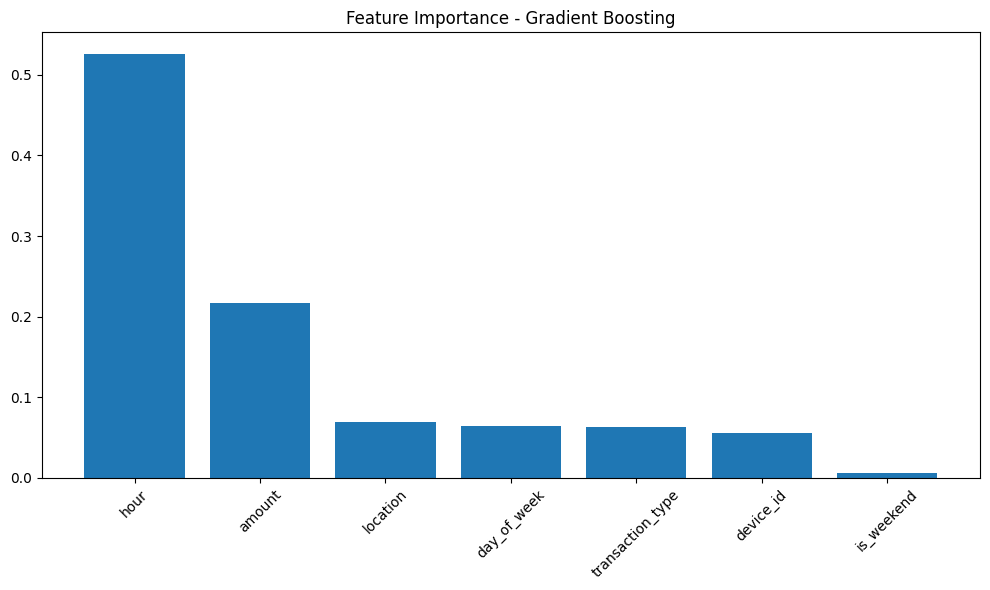

In [37]:
import matplotlib.pyplot as plt

model = best_model.named_steps['model']
selector = best_model.named_steps['select']
selected_features = selector.get_support(indices=True)
feature_names = X_train.columns[selected_features]

importances = model.feature_importances_
sorted_idx = importances.argsort()[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[sorted_idx], align='center')
plt.xticks(range(len(importances)), feature_names[sorted_idx], rotation=45)
plt.title("Feature Importance - Gradient Boosting")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

# Assuming you have a trained model `best_model`
# y_test: Actual labels from the test set
# X_test: Test data features

# Make predictions using your model
y_pred = best_model.predict(X_test)

# Compute classification report
report = classification_report(y_test, y_pred, output_dict=True)

# Calculate model metrics
metrics = {
    "Accuracy": report["accuracy"],
    "Precision": report["1"]["precision"],
    "Recall": report["1"]["recall"],
    "F1-Score": report["1"]["f1-score"],
    "ROC-AUC": roc_auc_score(y_test, y_pred)
}

print(metrics)

{'Accuracy': 0.991, 'Precision': 1.0, 'Recall': 0.8695652173913043, 'F1-Score': 0.9302325581395349, 'ROC-AUC': np.float64(0.9347826086956521)}


In [39]:
import joblib
# Save best model (e.g., Gradient Boosting) to specified path
with open(r"C:\Users\DELL\OneDrive\Desktop\SECURE_UPI\models\best_gboost_model.pkl", 'wb') as f:
    joblib.dump(tuned_results['Gradient Boosting']['best_estimator'], f)
print("Best model saved successfully")

Best model saved successfully


In [36]:
# Rebuild model and pipeline in your code
from imblearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest
from imblearn.over_sampling import SMOTE

# Example setup
pipeline = Pipeline([
    ('smote', SMOTE()),
    ('selectkbest', SelectKBest(k=5)),
    ('model', GradientBoostingClassifier())
])

# Fit your pipeline as usual
pipeline.fit(X_train, y_train)

# Now save with joblib (DO NOT use pickle)
import joblib
model_path = r'C:\Users\DELL\OneDrive\Desktop\SECURE_UPI\models\best_model.joblib'
model = joblib.dump(model,model_path)